# Term Project V3 - ทำนายราคาอสังหาริมทรัพย์ แยกตาม property_type (แบบแยกทีละกลุ่ม ไม่ใช้ loop)

ไฟล์นี้ปรับปรุงจาก V2 โดยยังคงโครงเดิม คือ **เขียนแยกทีละกลุ่ม** ไม่มี `for` วนทั้งตาราง

- ทุกขั้นตอน (เตรียมข้อมูล → train → tune → ทำนาย) ของแต่ละกลุ่มอยู่ในหมวดของตัวเอง
- ตัวแปรของแต่ละกลุ่มแยกกันชัดเจน เช่น `X_train_condo`, `model_house`, `new_condo`
- ปิดท้ายด้วยหมวด "รวมผล" ที่เอาผลของทั้ง 5 กลุ่มมาวางเทียบกัน

กลุ่มที่ต้องแยก: **Condo, Detached House, Townhouse, Apartment, Land**

ข้อมูล: `ddproperty_2022-04-19.csv`

## 0) สิ่งที่เปลี่ยนจาก V2

| # | ปัญหาใน V2 | วิธีแก้ใน V3 | ผลที่คาดหวัง |
|---|---|---|---|
| 1 | เลือก `max_depth` จาก R² บน **test set** แล้วรายงานผลบน test set เดิม ทำให้ตัวเลขดีเกินจริง | ใช้ `GridSearchCV` (5-fold CV) บน **train set เท่านั้น** แล้วใช้ test set ครั้งเดียวตอนท้าย | ตัวเลขบน test เป็นค่าที่เชื่อถือได้ |
| 2 | `dropna` คอลัมน์ coverage ต่ำ (`floor_level`, `furnished`, `tenure`) ทำให้ Condo เหลือ ~30% และบ้านเดี่ยวเหลือ ~15% | `dropna` เฉพาะคอลัมน์ที่จำเป็นจริง ส่วนคอลัมน์ข้อความที่ว่างเติมเป็น `'Unknown'` และคอลัมน์ตัวเลขที่ว่างเติมเป็น `-1` | ได้ข้อมูลกลับมาหลายเท่า และเป็นตัวแทนตลาดมากขึ้น |
| 3 | ราคาเบ้มาก บ้าน/ที่ดินแพงไม่กี่แปลงครอบงำ RMSE และ R² | เทรนบน `log(1 + price)` แล้วแปลงกลับเป็นบาท สำหรับ Land ทำนาย **ราคาต่อหน่วยพื้นที่** แล้วคูณ `land_space` กลับ | โมเดลไม่ถูกดึงด้วยราคาสุดโต่ง โดยเฉพาะ Land |
| 4 | `floor_level` ถูก `LabelEncoder` เรียงแบบตัวอักษร (`'10' < '2'`) | แปลงเป็นตัวเลขด้วย `pd.to_numeric` | ลำดับชั้นถูกต้อง |
| 5 | `median_real_price` เป็น `-` ทุกแถว เพราะ map ชื่อเขตกับรหัสตัวเลข | เก็บข้อมูลดิบ `new_*` ไว้ แล้ว encode ลงตัวแปรใหม่ `X_new_*` | เห็นราคากลางจริงของเขตไว้เทียบ |
| 6 | `price kept` ที่พิมพ์คำนวณ quantile **หลัง** กรอง จึงไม่ใช่ cutoff จริง | `prepare()` คืนค่า `hi_price` ที่ใช้กรองจริงออกมา | ตัวเลข cutoff ถูกต้อง |
| 7 | ชื่อเขต/จังหวัดที่ไม่รู้จักถูกแทนด้วย mode แบบเงียบ ๆ | `encode_column()` พิมพ์เตือนทุกครั้งที่เกิด fallback และแก้ตัวอย่าง Land ที่ใส่ `Bang Plee` เป็น `Bangkok` | รู้ตัวเมื่อผลทำนายมาจากเขตอื่น |
| 8 | กราฟ "Class Distribution" ไม่มีความหมายกับ regression และ Townhouse ไม่มีกราฟ | เปลี่ยนเป็น histogram ของราคาและ log ราคา ครบทั้ง 5 กลุ่ม | เห็นความเบ้ของราคาชัดเจน |
| 9 | Feature importance แบบ impurity อย่างเดียว ซึ่งเอนเอียงไปทาง feature ที่มีค่าหลากหลาย (`city`) | เพิ่ม `permutation_importance` บน test set เทียบ | ตีความความสำคัญได้น่าเชื่อถือขึ้น |
| 10 | มีแถวซ้ำแต่ไม่ได้ลบ (ทำให้แถวเดียวกันอาจอยู่ทั้ง train และ test) | `drop_duplicates()` ก่อนแบ่งกลุ่ม | ไม่มีข้อมูลรั่วระหว่าง train/test |

> **หมายเหตุ:** ชุด feature ของแต่ละกลุ่ม **ยังเหมือน V2 ทุกตัว** เพื่อให้เห็นว่าผลที่เปลี่ยนมาจากระเบียบวิธี ไม่ใช่จากการเพิ่ม feature

## 1) Import library

In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TEST_SIZE = 0.3
PRICE_QUANTILE = 0.99
MIN_PRICE = 100_000

# ช่วงค่าที่ให้ GridSearchCV ลอง
PARAM_GRID = {
    'max_depth': [3, 5, 8, 10, 12, 15, None],
    'min_samples_leaf': [1, 5, 20],
}
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 2) Read File

ลบแถวที่ซ้ำกันทุกคอลัมน์ทิ้งตั้งแต่ตอนนี้ ไม่อย่างนั้นแถวเดียวกันอาจไปอยู่ทั้งใน train และ test ทำให้ผลดีเกินจริง

In [11]:
df = pd.read_csv('ddproperty_2022-04-19.csv', low_memory=False)
print('shape      :', df.shape)
print('duplicated :', df.duplicated().sum())

df = df.drop_duplicates()
print('shape after drop_duplicates:', df.shape)

shape      : (220557, 69)
duplicated : 0
shape after drop_duplicates: (220557, 69)


## 3) ลบคอลัมน์ที่เป็น null ทั้งหมด

คอลัมน์ที่ไม่มีข้อมูลเลยไม่มีประโยชน์กับโมเดล จึงตัดทิ้งก่อน

In [12]:
all_null_cols = [c for c in df.columns if df[c].isnull().all()]
print('all-null columns:', len(all_null_cols))

df = df.drop(columns=all_null_cols)
print('shape after drop:', df.shape)

all-null columns: 21
shape after drop: (220557, 48)


## 4) แยกเป็น 5 กลุ่ม (เขียนแยกทีละบรรทัด ไม่ใช้ `groupby` วน)

ถ้าใช้ `df.dropna()` ทั้งตารางจะเหลือข้อมูลไม่กี่ร้อยแถว เพราะ `land_space` null 61% และ `living_space` null 14.5%

วิธีแก้คือ **แยกกลุ่มก่อน แล้วจัดการ null ตามคอลัมน์ที่แต่ละกลุ่มต้องใช้**

In [13]:
df_condo = df[df['property_type'] == 'Condo'].copy()
df_house = df[df['property_type'] == 'Detached House'].copy()
df_townhouse = df[df['property_type'] == 'Townhouse'].copy()
df_apartment = df[df['property_type'] == 'Apartment'].copy()
df_land = df[df['property_type'] == 'Land'].copy()

print('df_condo    ', df_condo.shape)
print('df_house    ', df_house.shape)
print('df_townhouse', df_townhouse.shape)
print('df_apartment', df_apartment.shape)
print('df_land     ', df_land.shape)

df_condo     (129129, 48)
df_house     (42721, 48)
df_townhouse (18697, 48)
df_apartment (4553, 48)
df_land      (25457, 48)


## 5) คอลัมน์ที่เลือกใช้ของแต่ละกลุ่ม

coverage (สัดส่วนแถวที่มีข้อมูล) ของคอลัมน์รองในแต่ละกลุ่ม:

| กลุ่ม | built_year | floor_level | tenure | furnished | land_space |
|---|---|---|---|---|---|
| Condo | 81.1% | 43.4% | 77.4% | 53.0% | 0% |
| Detached House | 4.3% | 40.5% | 26.5% | 42.4% | 93.1% |
| Townhouse | 5.8% | 74.2% | 33.8% | 33.1% | 91.4% |
| Apartment | 2.2% | 60.3% | 27.9% | 53.4% | 71.1% |
| Land | 0.3% | 4.6% | 29.6% | 0.1% | 100.0% |

แบ่งคอลัมน์เป็น 2 แบบ:

- **คอลัมน์จำเป็น** (`required`) ถ้าว่างจะลบแถวทิ้ง ได้แก่ `price`, `city`, `state` และพื้นที่หลักของกลุ่มนั้น (`living_space` หรือ `land_space` สำหรับ Land)
- **คอลัมน์เสริม** ถ้าว่างจะ **เติมค่า** แทนการลบแถว
  - ข้อความ (`tenure`, `furnished`) เติมเป็น `'Unknown'` ซึ่งกลายเป็นหมวดหนึ่งที่ต้นไม้ใช้แยกได้
  - ตัวเลข (`floor_level`, `built_year`, `bedroom_number`, ...) เติมเป็น `-1` ซึ่งต้นไม้แยกออกจากค่าจริงได้ด้วยการแบ่งครั้งเดียว

คอลัมน์ที่ coverage ต่ำมาก (< 6%) ยังตัดออกเหมือนเดิม เพราะเกือบทั้งหมดจะเป็นค่าที่เติม ไม่มีข้อมูลให้เรียนรู้

- `land_space` ของ Condo = **0%** (คอนโดไม่มีขนาดที่ดิน)
- `built_year` ของบ้าน/ทาวน์เฮาส์/อพาร์ตเมนต์ < 6%
- `Land` ใช้แค่ `land_space`, `city`, `state` เพราะ `living_space` = **0%** และคอลัมน์อื่น coverage ต่ำ

> สำหรับบ้านเดี่ยวและทาวน์เฮาส์ `floor_level` น่าจะหมายถึง **จำนวนชั้นของตัวบ้าน** ไม่ใช่ชั้นที่ห้องอยู่เหมือนคอนโด

## 6) ฟังก์ชันช่วยเตรียมข้อมูลและประเมินผล

ใช้ฟังก์ชันเดียวกันทั้ง 5 กลุ่ม แต่ **เรียกแยกทีละกลุ่ม** ในหมวดของแต่ละกลุ่ม

**เรื่อง target แบบ log:** ราคาอสังหาเบ้ขวามาก (ส่วนใหญ่หลักล้าน แต่มีบางแปลงหลายร้อยล้าน) ถ้าเทรนบนราคาตรง ๆ ต้นไม้จะพยายามแบ่งเพื่อลด error ของรายการแพงไม่กี่รายการ จึงเทรนบน `log(1 + price)` ซึ่งทำให้ error กลายเป็น **error แบบสัดส่วน** (พลาด 10% ของบ้าน 2 ล้าน กับ 10% ของบ้าน 20 ล้าน มีน้ำหนักเท่ากัน) แล้วแปลงกลับเป็นบาทด้วย `expm1` ตอนทำนาย

**ตัววัดผล** (คำนวณบน test set ทุกตัว):

| ตัววัด | ความหมาย |
|---|---|
| `MAE` | คลาดเฉลี่ยกี่บาท |
| `RMSE` | เหมือน MAE แต่ลงโทษความคลาดที่ใหญ่มากหนักกว่า |
| `R2` | R² บนราคาเป็นบาท (เทียบกับ V2 ได้ตรง ๆ) ถูกครอบงำด้วยรายการราคาแพง |
| `R2_log` | R² บน log ราคา บอกว่าโมเดลจับ **สัดส่วน** ราคาได้ดีแค่ไหนทั้งตลาด |
| `MdAPE` | ค่ามัธยฐานของ % ที่คลาด เช่น 15% แปลว่าครึ่งหนึ่งของรายการทำนายพลาดไม่เกิน 15% อ่านง่ายที่สุด |

In [14]:
def prepare(data, required, numeric, categorical, quantile=PRICE_QUANTILE):
    """ลบแถวที่คอลัมน์จำเป็นว่าง เติมค่าคอลัมน์เสริม แล้วกรองราคา outlier

    คืนค่า (ข้อมูลที่ใช้, X, price, hi_price) โดย hi_price คือ cutoff ที่ใช้กรองจริง
    """
    data = data.dropna(subset=['price'] + required).copy()

    # พื้นที่ต้องมากกว่า 0 (พื้นที่ 0 คือกรอกผิด และทำให้ราคาต่อพื้นที่หารไม่ได้)
    for col in required:
        if col in numeric:
            data = data[pd.to_numeric(data[col], errors='coerce') > 0]

    hi_price = data['price'].quantile(quantile)       # คำนวณก่อนกรอง
    data = data[(data['price'] >= MIN_PRICE) & (data['price'] <= hi_price)].copy()

    # ตัวเลข: แปลงเป็นตัวเลขจริง (เช่น floor_level '12' -> 12) ค่าที่แปลงไม่ได้/ว่าง = -1
    for col in numeric:
        data[col] = pd.to_numeric(data[col], errors='coerce').fillna(-1)
    # ข้อความ: ว่าง = 'Unknown'
    for col in categorical:
        data[col] = data[col].fillna('Unknown').astype(str)

    X = data[numeric + categorical].copy()
    return data, X, data['price'], hi_price


def to_target(price, X, per_area=None):
    """แปลงราคาเป็น target ที่ใช้เทรน: log(1 + price) หรือ log(1 + price / พื้นที่)"""
    if per_area is None:
        return np.log1p(price)
    return np.log1p(price / X[per_area])


def predict_price(model, X, per_area=None):
    """ทำนายแล้วแปลงกลับเป็นราคา (บาท)"""
    pred = np.expm1(model.predict(X))
    if per_area is not None:
        pred = pred * X[per_area].to_numpy()
    return pred


def metrics(model, X_test, price_test, per_area=None):
    """คำนวณ MAE / RMSE / R2 (บาท) / R2_log / MdAPE ของโมเดล"""
    pred = predict_price(model, X_test, per_area)
    return {
        'MAE': mean_absolute_error(price_test, pred),
        'RMSE': np.sqrt(mean_squared_error(price_test, pred)),
        'R2': r2_score(price_test, pred),
        'R2_log': r2_score(np.log1p(price_test), np.log1p(pred)),
        'MdAPE': np.median(np.abs(pred - price_test) / price_test) * 100,
    }


def report(model, X_test, price_test, model_name, per_area=None):
    """พิมพ์รายละเอียดของโมเดล แล้วคืนค่า metrics"""
    m = metrics(model, X_test, price_test, per_area)
    print(f'===== {model_name} =====')
    print(f'depth  = {model.get_depth()}')
    print(f'leaves = {model.get_n_leaves():,}')
    print(f"MAE    : {m['MAE']:,.0f}")
    print(f"RMSE   : {m['RMSE']:,.0f}")
    print(f"R²     : {m['R2']:.4f}")
    print(f"R² log : {m['R2_log']:.4f}")
    print(f"MdAPE  : {m['MdAPE']:.1f}%")
    print()
    return m


def tune(X_train, y_train, name):
    """หา max_depth / min_samples_leaf ด้วย 5-fold CV บน train set เท่านั้น"""
    grid = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                        PARAM_GRID, cv=CV, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)

    params = grid.cv_results_['params']
    table = pd.DataFrame({
        'max_depth': [str(p['max_depth']) for p in params],
        'min_samples_leaf': [p['min_samples_leaf'] for p in params],
        'cv_R2_log': grid.cv_results_['mean_test_score'],
    })
    table = table.pivot(index='max_depth', columns='min_samples_leaf', values='cv_R2_log')
    table = table.reindex([str(d) for d in PARAM_GRID['max_depth']])
    table.columns = [f'leaf={c}' for c in table.columns]

    print(f'===== {name}: CV R² (log price) บน train set =====')
    print(table.round(4).to_string())
    print('best params :', grid.best_params_)
    print(f'best CV R²  : {grid.best_score_:.4f}')
    return grid


def plot_price_distribution(price, name, hi_price):
    """histogram ของราคา (บาท) และ log10 ราคา"""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].hist(price / 1e6, bins=60)
    axes[0].set_xlabel('price (million THB)')
    axes[0].set_ylabel('listings')
    axes[0].set_title(f'{name}: price')
    axes[1].hist(np.log10(price), bins=60)
    axes[1].set_xlabel('log10(price)')
    axes[1].set_title(f'{name}: log10(price)')
    fig.suptitle(f'kept {MIN_PRICE:,} – {hi_price:,.0f} THB', fontsize=9)
    plt.tight_layout()
    plt.show()


def importance_table(model, X_test, y_test, features):
    """เทียบ importance แบบ impurity (จากต้นไม้) กับแบบ permutation (บน test set)"""
    perm = permutation_importance(model, X_test, y_test, n_repeats=5,
                                  random_state=RANDOM_STATE, scoring='r2', n_jobs=-1)
    return pd.DataFrame({
        'impurity': model.feature_importances_,
        'permutation': perm.importances_mean,
    }, index=features).sort_values('permutation', ascending=False)


def encode_column(values, encoder, fallback, col_name):
    """แปลงค่าข้อความเป็นตัวเลข ถ้าไม่เคยเจอในข้อมูลฝึกจะใช้ค่าที่พบบ่อยสุด และพิมพ์เตือน"""
    values = values.fillna('Unknown').astype(str)
    mapping = {name: code for code, name in enumerate(encoder.classes_)}
    codes = values.map(mapping)
    unknown = values[codes.isna()].unique()
    if len(unknown) > 0:
        print(f'⚠ {col_name}: ไม่พบ {list(unknown)} ในข้อมูลฝึก '
              f'→ ใช้ {encoder.classes_[fallback]!r} แทน (ผลทำนายแถวนี้อาจไม่ตรงพื้นที่จริง)')
    return codes.fillna(fallback).astype(int)

---

# 7) Condo

กลุ่มนี้มีข้อมูลเยอะที่สุด (~59%) และ **ไม่มี `land_space` เลย**

ราคาคอนโดผูกกับ `living_space` ปีที่สร้าง และทำเล

### 7.1 Condo — เตรียมข้อมูลและแบ่ง train/test

rows=126,431 จาก 129,129 (98%)  train=88,501  test=37,930
price kept: 100,000 - 80,000,000


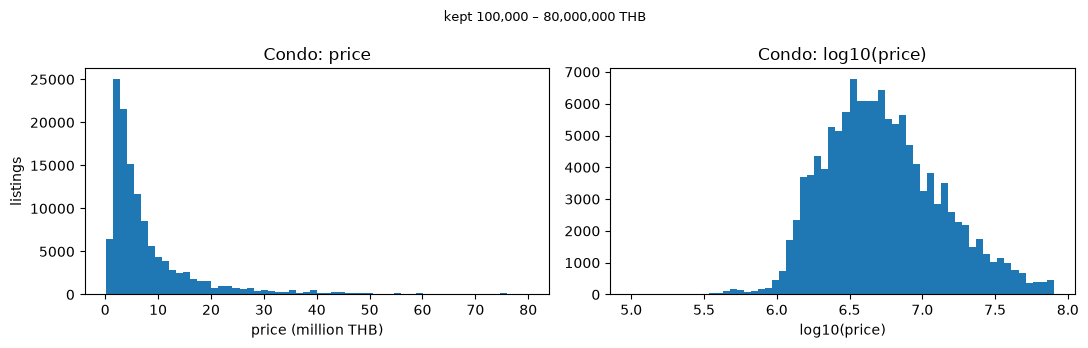

In [15]:
NUMERIC_CONDO = ['living_space', 'bedroom_number', 'bathroom_number', 'built_year', 'floor_level']
CATEGORICAL_CONDO = ['tenure', 'city', 'state']
FEATURES_CONDO = NUMERIC_CONDO + CATEGORICAL_CONDO
PER_AREA_CONDO = None

condo, X_condo, price_condo, hi_price_condo = prepare(
    df_condo, required=['living_space', 'city', 'state'],
    numeric=NUMERIC_CONDO, categorical=CATEGORICAL_CONDO)

# คอลัมน์ข้อความของ Condo: tenure, city, state
tenure_enc_condo = LabelEncoder().fit(X_condo['tenure'])
city_enc_condo = LabelEncoder().fit(X_condo['city'])
state_enc_condo = LabelEncoder().fit(X_condo['state'])

X_condo['tenure'] = tenure_enc_condo.transform(X_condo['tenure'])
X_condo['city'] = city_enc_condo.transform(X_condo['city'])
X_condo['state'] = state_enc_condo.transform(X_condo['state'])

X_train_condo, X_test_condo, price_train_condo, price_test_condo = train_test_split(
    X_condo, price_condo, test_size=TEST_SIZE, random_state=RANDOM_STATE)

y_train_condo = to_target(price_train_condo, X_train_condo, PER_AREA_CONDO)
y_test_condo = to_target(price_test_condo, X_test_condo, PER_AREA_CONDO)

print(f'rows={len(condo):,} จาก {len(df_condo):,} ({len(condo) / len(df_condo):.0%})  '
      f'train={len(X_train_condo):,}  test={len(X_test_condo):,}')
print(f'price kept: {MIN_PRICE:,} - {hi_price_condo:,.0f}')

plot_price_distribution(price_condo, 'Condo', hi_price_condo)

### 7.2 Condo — DecisionTreeRegressor ค่า default

ค่า default ไม่จำกัดความลึก ต้นไม้จะโตจนจำข้อมูลฝึก (overfit) ใช้เป็น baseline ไว้เทียบ

In [16]:
model_condo_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_condo_default.fit(X_train_condo, y_train_condo)

res_condo_default = report(
    model_condo_default, X_test_condo, price_test_condo, 'DT default Condo', PER_AREA_CONDO)

===== DT default Condo =====
depth  = 37
leaves = 45,727
MAE    : 1,531,713
RMSE   : 4,152,208
R²     : 0.8468
R² log : 0.8625
MdAPE  : 9.1%



### 7.3 Condo — Tune `max_depth` และ `min_samples_leaf` ด้วย 5-fold CV

`GridSearchCV` แบ่ง **train set** เป็น 5 ส่วน เทรน 4 ส่วนแล้ววัดผลส่วนที่เหลือ วนจนครบ แล้วเฉลี่ย R² จึงไม่แตะ test set เลย

- `max_depth` จำกัดความลึกของต้นไม้
- `min_samples_leaf` บังคับให้ใบแต่ละใบมีข้อมูลอย่างน้อยกี่แถว ช่วยให้ค่าทำนายของแต่ละใบนิ่งขึ้น โดยเฉพาะกลุ่มที่ข้อมูลน้อย

In [17]:
grid_condo = tune(X_train_condo, y_train_condo, 'Condo')

===== Condo: CV R² (log price) บน train set =====
           leaf=1  leaf=5  leaf=20
max_depth                         
3          0.6643  0.6643   0.6643
5          0.7467  0.7467   0.7467
8          0.8035  0.8049   0.8042
10         0.8311  0.8328   0.8311
12         0.8470  0.8501   0.8472
15         0.8588  0.8668   0.8583
None       0.8558  0.8740   0.8611
best params : {'max_depth': None, 'min_samples_leaf': 5}
best CV R²  : 0.8740


### 7.4 Condo — Final model

ใช้ค่าที่ CV เลือก (`grid_condo.best_params_`) แล้ววัดผลบน test set **ครั้งเดียว**

In [18]:
BEST_PARAMS_CONDO = grid_condo.best_params_
model_condo = grid_condo.best_estimator_   # GridSearchCV เทรนใหม่บน train set ทั้งหมดให้แล้ว

res_condo_tuned = report(
    model_condo, X_test_condo, price_test_condo, 'DT tuned Condo', PER_AREA_CONDO)

===== DT tuned Condo =====
depth  = 29
leaves = 10,890
MAE    : 1,637,586
RMSE   : 3,942,246
R²     : 0.8619
R² log : 0.8783
MdAPE  : 11.6%



### 7.5 Condo — Feature Importance

- `impurity` คือค่า `feature_importances_` ของต้นไม้ เอนเอียงไปทาง feature ที่มีค่าไม่ซ้ำเยอะ (เช่น `city`)
- `permutation` คือ R² (log) ที่ลดลงเมื่อสลับค่าของ feature นั้นใน test set แบบสุ่ม ยิ่งลดมากยิ่งสำคัญ น่าเชื่อถือกว่า

In [19]:
importance_condo = importance_table(model_condo, X_test_condo, y_test_condo, FEATURES_CONDO)
importance_condo.round(4)

,impurity,permutation
living_space,0.7286,1.1986
city,0.0768,0.2165
built_year,0.0957,0.2128
state,0.0411,0.1223
floor_level,0.0320,0.0438
bathroom_number,0.0123,0.0334
bedroom_number,0.0069,0.0310
tenure,0.0065,0.0259


### 7.6 Condo — ทดลองทำนายของใหม่

`new_condo` เก็บค่าดิบ (ชื่อเขตเป็นข้อความ) ส่วน `X_new_condo` คือค่าที่ encode แล้วสำหรับส่งเข้าโมเดล
`median_real_price` จึง map จากชื่อเขตได้ถูกต้อง

In [20]:
tenure_mode_condo = int(X_train_condo['tenure'].mode()[0])
city_mode_condo = int(X_train_condo['city'].mode()[0])
state_mode_condo = int(X_train_condo['state'].mode()[0])

new_condo = pd.DataFrame([
    {'living_space': 35, 'bedroom_number': 1, 'bathroom_number': 1,
     'built_year': 2018, 'floor_level': '12', 'tenure': 'Freehold',
     'city': 'Watthana', 'state': 'Bangkok'},
    {'living_space': 120, 'bedroom_number': 3, 'bathroom_number': 3,
     'built_year': 2021, 'floor_level': '25', 'tenure': 'Freehold',
     'city': 'Bang Rak', 'state': 'Bangkok'},
])

X_new_condo = new_condo[FEATURES_CONDO].copy()
X_new_condo[NUMERIC_CONDO] = X_new_condo[NUMERIC_CONDO].apply(pd.to_numeric, errors='coerce').fillna(-1)
X_new_condo['tenure'] = encode_column(new_condo['tenure'], tenure_enc_condo, tenure_mode_condo, 'tenure')
X_new_condo['city'] = encode_column(new_condo['city'], city_enc_condo, city_mode_condo, 'city')
X_new_condo['state'] = encode_column(new_condo['state'], state_enc_condo, state_mode_condo, 'state')

new_condo['property_type'] = 'Condo'
new_condo['predicted_price'] = predict_price(model_condo, X_new_condo, PER_AREA_CONDO)

median_condo = condo.groupby('city')['price'].median()
new_condo['median_real_price'] = new_condo['city'].map(median_condo)

new_condo[['property_type', 'living_space', 'state', 'city', 'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,living_space,state,city,predicted_price,median_real_price
0,Condo,35,Bangkok,Watthana,7737533.0,9600000.0
1,Condo,120,Bangkok,Bang Rak,29751613.0,9750000.0


---

# 8) Detached House

บ้านเดี่ยวมีทั้งพื้นที่ใช้สอยและขนาดที่ดิน แต่ `built_year` มีข้อมูลแค่ 4.3% จึงตัดออก

ใน V2 กลุ่มนี้เหลือข้อมูลแค่ ~15% เพราะ `dropna` ของ `floor_level` และ `furnished` ตอนนี้เติมค่าแทนแล้ว

### 8.1 Detached House — เตรียมข้อมูลและแบ่ง train/test

rows=38,629 จาก 42,721 (90%)  train=27,040  test=11,589
price kept: 100,000 - 170,000,000


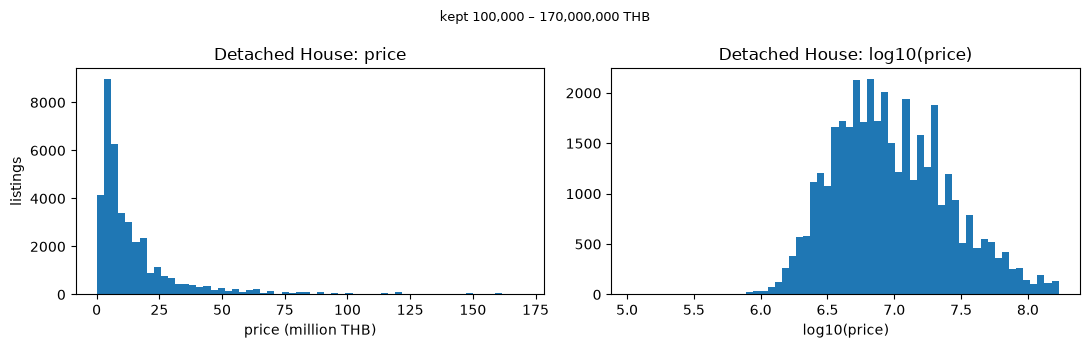

In [21]:
NUMERIC_HOUSE = ['living_space', 'land_space', 'bedroom_number', 'bathroom_number', 'floor_level']
CATEGORICAL_HOUSE = ['furnished', 'city', 'state']
FEATURES_HOUSE = NUMERIC_HOUSE + CATEGORICAL_HOUSE
PER_AREA_HOUSE = None

house, X_house, price_house, hi_price_house = prepare(
    df_house, required=['living_space', 'city', 'state'],
    numeric=NUMERIC_HOUSE, categorical=CATEGORICAL_HOUSE)

# คอลัมน์ข้อความของ Detached House: furnished, city, state
furnished_enc_house = LabelEncoder().fit(X_house['furnished'])
city_enc_house = LabelEncoder().fit(X_house['city'])
state_enc_house = LabelEncoder().fit(X_house['state'])

X_house['furnished'] = furnished_enc_house.transform(X_house['furnished'])
X_house['city'] = city_enc_house.transform(X_house['city'])
X_house['state'] = state_enc_house.transform(X_house['state'])

X_train_house, X_test_house, price_train_house, price_test_house = train_test_split(
    X_house, price_house, test_size=TEST_SIZE, random_state=RANDOM_STATE)

y_train_house = to_target(price_train_house, X_train_house, PER_AREA_HOUSE)
y_test_house = to_target(price_test_house, X_test_house, PER_AREA_HOUSE)

print(f'rows={len(house):,} จาก {len(df_house):,} ({len(house) / len(df_house):.0%})  '
      f'train={len(X_train_house):,}  test={len(X_test_house):,}')
print(f'price kept: {MIN_PRICE:,} - {hi_price_house:,.0f}')

plot_price_distribution(price_house, 'Detached House', hi_price_house)

### 8.2 Detached House — DecisionTreeRegressor ค่า default

ค่า default ไม่จำกัดความลึก ต้นไม้จะโตจนจำข้อมูลฝึก (overfit) ใช้เป็น baseline ไว้เทียบ

In [22]:
model_house_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_house_default.fit(X_train_house, y_train_house)

res_house_default = report(
    model_house_default, X_test_house, price_test_house, 'DT default Detached House', PER_AREA_HOUSE)

===== DT default Detached House =====
depth  = 38
leaves = 22,790
MAE    : 6,350,067
RMSE   : 15,901,424
R²     : 0.4835
R² log : 0.6700
MdAPE  : 18.9%



### 8.3 Detached House — Tune `max_depth` และ `min_samples_leaf` ด้วย 5-fold CV

`GridSearchCV` แบ่ง **train set** เป็น 5 ส่วน เทรน 4 ส่วนแล้ววัดผลส่วนที่เหลือ วนจนครบ แล้วเฉลี่ย R² จึงไม่แตะ test set เลย

- `max_depth` จำกัดความลึกของต้นไม้
- `min_samples_leaf` บังคับให้ใบแต่ละใบมีข้อมูลอย่างน้อยกี่แถว ช่วยให้ค่าทำนายของแต่ละใบนิ่งขึ้น โดยเฉพาะกลุ่มที่ข้อมูลน้อย

In [23]:
grid_house = tune(X_train_house, y_train_house, 'Detached House')

===== Detached House: CV R² (log price) บน train set =====
           leaf=1  leaf=5  leaf=20
max_depth                         
3          0.5816  0.5816   0.5816
5          0.6513  0.6508   0.6498
8          0.7085  0.7083   0.7080
10         0.7106  0.7224   0.7252
12         0.6975  0.7234   0.7316
15         0.6661  0.7192   0.7331
None       0.6310  0.7157   0.7334
best params : {'max_depth': None, 'min_samples_leaf': 20}
best CV R²  : 0.7334


### 8.4 Detached House — Final model

ใช้ค่าที่ CV เลือก (`grid_house.best_params_`) แล้ววัดผลบน test set **ครั้งเดียว**

In [24]:
BEST_PARAMS_HOUSE = grid_house.best_params_
model_house = grid_house.best_estimator_   # GridSearchCV เทรนใหม่บน train set ทั้งหมดให้แล้ว

res_house_tuned = report(
    model_house, X_test_house, price_test_house, 'DT tuned Detached House', PER_AREA_HOUSE)

===== DT tuned Detached House =====
depth  = 20
leaves = 1,011
MAE    : 6,266,507
RMSE   : 14,027,293
R²     : 0.5980
R² log : 0.7558
MdAPE  : 24.9%



### 8.5 Detached House — Feature Importance

- `impurity` คือค่า `feature_importances_` ของต้นไม้ เอนเอียงไปทาง feature ที่มีค่าไม่ซ้ำเยอะ (เช่น `city`)
- `permutation` คือ R² (log) ที่ลดลงเมื่อสลับค่าของ feature นั้นใน test set แบบสุ่ม ยิ่งลดมากยิ่งสำคัญ น่าเชื่อถือกว่า

In [25]:
importance_house = importance_table(model_house, X_test_house, y_test_house, FEATURES_HOUSE)
importance_house.round(4)

,impurity,permutation
living_space,0.5953,0.2657
bathroom_number,0.1884,0.2653
state,0.0729,0.1824
land_space,0.0690,0.1346
city,0.0549,0.0862
floor_level,0.0065,0.0152
furnished,0.0070,0.0107
bedroom_number,0.0059,0.0087


### 8.6 Detached House — ทดลองทำนายของใหม่

`new_house` เก็บค่าดิบ (ชื่อเขตเป็นข้อความ) ส่วน `X_new_house` คือค่าที่ encode แล้วสำหรับส่งเข้าโมเดล
`median_real_price` จึง map จากชื่อเขตได้ถูกต้อง

In [26]:
furnished_mode_house = int(X_train_house['furnished'].mode()[0])
city_mode_house = int(X_train_house['city'].mode()[0])
state_mode_house = int(X_train_house['state'].mode()[0])

new_house = pd.DataFrame([
    {'living_space': 250, 'land_space': 400, 'bedroom_number': 4,
     'bathroom_number': 4, 'floor_level': '2',
     'furnished': 'Fully Furnished', 'city': 'Hua Hin',
     'state': 'Prachuap Khiri Khan'},
    {'living_space': 120, 'land_space': 200, 'bedroom_number': 3,
     'bathroom_number': 2, 'floor_level': '1',
     'furnished': 'Unfurnished', 'city': 'Bang Plee',
     'state': 'Samut Prakan'},
])

X_new_house = new_house[FEATURES_HOUSE].copy()
X_new_house[NUMERIC_HOUSE] = X_new_house[NUMERIC_HOUSE].apply(pd.to_numeric, errors='coerce').fillna(-1)
X_new_house['furnished'] = encode_column(new_house['furnished'], furnished_enc_house, furnished_mode_house, 'furnished')
X_new_house['city'] = encode_column(new_house['city'], city_enc_house, city_mode_house, 'city')
X_new_house['state'] = encode_column(new_house['state'], state_enc_house, state_mode_house, 'state')

new_house['property_type'] = 'Detached House'
new_house['predicted_price'] = predict_price(model_house, X_new_house, PER_AREA_HOUSE)

median_house = house.groupby('city')['price'].median()
new_house['median_real_price'] = new_house['city'].map(median_house)

new_house[['property_type', 'living_space', 'land_space', 'state', 'city', 'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,living_space,land_space,state,city,predicted_price,median_real_price
0,Detached House,250,400,Prachuap Khiri Khan,Hua Hin,8587177.0,8000000.0
1,Detached House,120,200,Samut Prakan,Bang Plee,3480084.0,8497500.0


---

# 9) Townhouse

ชุด feature เหมือน Detached House แต่ข้อมูลน้อยกว่า (~8.5%) และราคากระจายแคบกว่า

`land_space` ยังไม่อยู่ใน `required` (เติม `-1` ถ้าว่าง) เพราะทาวน์เฮาส์บางประกาศไม่ระบุขนาดที่ดิน

### 9.1 Townhouse — เตรียมข้อมูลและแบ่ง train/test

rows=16,095 จาก 18,697 (86%)  train=11,266  test=4,829
price kept: 100,000 - 41,772,000


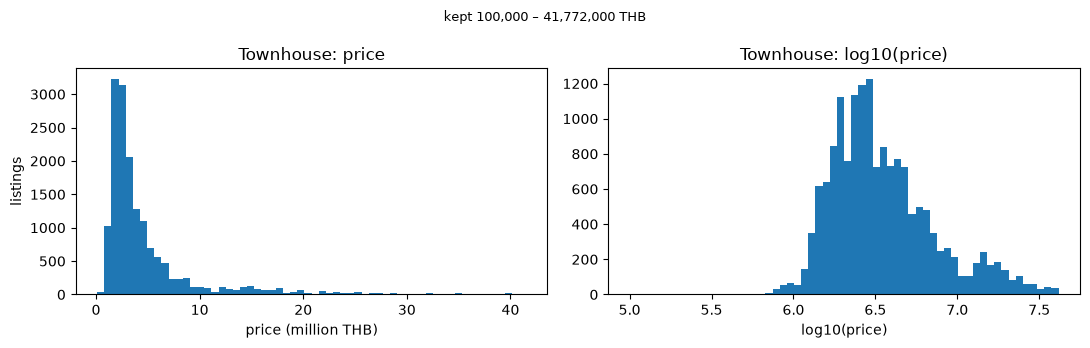

In [27]:
NUMERIC_TOWNHOUSE = ['living_space', 'land_space', 'bedroom_number', 'bathroom_number', 'floor_level']
CATEGORICAL_TOWNHOUSE = ['furnished', 'city', 'state']
FEATURES_TOWNHOUSE = NUMERIC_TOWNHOUSE + CATEGORICAL_TOWNHOUSE
PER_AREA_TOWNHOUSE = None

townhouse, X_townhouse, price_townhouse, hi_price_townhouse = prepare(
    df_townhouse, required=['living_space', 'city', 'state'],
    numeric=NUMERIC_TOWNHOUSE, categorical=CATEGORICAL_TOWNHOUSE)

# คอลัมน์ข้อความของ Townhouse: furnished, city, state
furnished_enc_townhouse = LabelEncoder().fit(X_townhouse['furnished'])
city_enc_townhouse = LabelEncoder().fit(X_townhouse['city'])
state_enc_townhouse = LabelEncoder().fit(X_townhouse['state'])

X_townhouse['furnished'] = furnished_enc_townhouse.transform(X_townhouse['furnished'])
X_townhouse['city'] = city_enc_townhouse.transform(X_townhouse['city'])
X_townhouse['state'] = state_enc_townhouse.transform(X_townhouse['state'])

X_train_townhouse, X_test_townhouse, price_train_townhouse, price_test_townhouse = train_test_split(
    X_townhouse, price_townhouse, test_size=TEST_SIZE, random_state=RANDOM_STATE)

y_train_townhouse = to_target(price_train_townhouse, X_train_townhouse, PER_AREA_TOWNHOUSE)
y_test_townhouse = to_target(price_test_townhouse, X_test_townhouse, PER_AREA_TOWNHOUSE)

print(f'rows={len(townhouse):,} จาก {len(df_townhouse):,} ({len(townhouse) / len(df_townhouse):.0%})  '
      f'train={len(X_train_townhouse):,}  test={len(X_test_townhouse):,}')
print(f'price kept: {MIN_PRICE:,} - {hi_price_townhouse:,.0f}')

plot_price_distribution(price_townhouse, 'Townhouse', hi_price_townhouse)

### 9.2 Townhouse — DecisionTreeRegressor ค่า default

ค่า default ไม่จำกัดความลึก ต้นไม้จะโตจนจำข้อมูลฝึก (overfit) ใช้เป็น baseline ไว้เทียบ

In [28]:
model_townhouse_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_townhouse_default.fit(X_train_townhouse, y_train_townhouse)

res_townhouse_default = report(
    model_townhouse_default, X_test_townhouse, price_test_townhouse, 'DT default Townhouse', PER_AREA_TOWNHOUSE)

===== DT default Townhouse =====
depth  = 31
leaves = 9,764
MAE    : 1,396,959
RMSE   : 3,247,431
R²     : 0.6357
R² log : 0.7061
MdAPE  : 16.2%



### 9.3 Townhouse — Tune `max_depth` และ `min_samples_leaf` ด้วย 5-fold CV

`GridSearchCV` แบ่ง **train set** เป็น 5 ส่วน เทรน 4 ส่วนแล้ววัดผลส่วนที่เหลือ วนจนครบ แล้วเฉลี่ย R² จึงไม่แตะ test set เลย

- `max_depth` จำกัดความลึกของต้นไม้
- `min_samples_leaf` บังคับให้ใบแต่ละใบมีข้อมูลอย่างน้อยกี่แถว ช่วยให้ค่าทำนายของแต่ละใบนิ่งขึ้น โดยเฉพาะกลุ่มที่ข้อมูลน้อย

In [29]:
grid_townhouse = tune(X_train_townhouse, y_train_townhouse, 'Townhouse')

===== Townhouse: CV R² (log price) บน train set =====
           leaf=1  leaf=5  leaf=20
max_depth                         
3          0.6184  0.6184   0.6184
5          0.6930  0.6963   0.6962
8          0.7288  0.7323   0.7352
10         0.7241  0.7362   0.7429
12         0.7074  0.7358   0.7457
15         0.6792  0.7335   0.7457
None       0.6630  0.7319   0.7457
best params : {'max_depth': 12, 'min_samples_leaf': 20}
best CV R²  : 0.7457


### 9.4 Townhouse — Final model

ใช้ค่าที่ CV เลือก (`grid_townhouse.best_params_`) แล้ววัดผลบน test set **ครั้งเดียว**

In [30]:
BEST_PARAMS_TOWNHOUSE = grid_townhouse.best_params_
model_townhouse = grid_townhouse.best_estimator_   # GridSearchCV เทรนใหม่บน train set ทั้งหมดให้แล้ว

res_townhouse_tuned = report(
    model_townhouse, X_test_townhouse, price_test_townhouse, 'DT tuned Townhouse', PER_AREA_TOWNHOUSE)

===== DT tuned Townhouse =====
depth  = 12
leaves = 376
MAE    : 1,379,651
RMSE   : 2,948,881
R²     : 0.6996
R² log : 0.7760
MdAPE  : 18.1%



### 9.5 Townhouse — Feature Importance

- `impurity` คือค่า `feature_importances_` ของต้นไม้ เอนเอียงไปทาง feature ที่มีค่าไม่ซ้ำเยอะ (เช่น `city`)
- `permutation` คือ R² (log) ที่ลดลงเมื่อสลับค่าของ feature นั้นใน test set แบบสุ่ม ยิ่งลดมากยิ่งสำคัญ น่าเชื่อถือกว่า

In [31]:
importance_townhouse = importance_table(model_townhouse, X_test_townhouse, y_test_townhouse, FEATURES_TOWNHOUSE)
importance_townhouse.round(4)

,impurity,permutation
bathroom_number,0.5332,0.2428
living_space,0.2557,0.2203
state,0.0657,0.1436
city,0.0733,0.0999
land_space,0.0391,0.0657
floor_level,0.0135,0.0245
bedroom_number,0.0169,0.0213
furnished,0.0026,0.0025


### 9.6 Townhouse — ทดลองทำนายของใหม่

`new_townhouse` เก็บค่าดิบ (ชื่อเขตเป็นข้อความ) ส่วน `X_new_townhouse` คือค่าที่ encode แล้วสำหรับส่งเข้าโมเดล
`median_real_price` จึง map จากชื่อเขตได้ถูกต้อง

In [32]:
furnished_mode_townhouse = int(X_train_townhouse['furnished'].mode()[0])
city_mode_townhouse = int(X_train_townhouse['city'].mode()[0])
state_mode_townhouse = int(X_train_townhouse['state'].mode()[0])

new_townhouse = pd.DataFrame([
    {'living_space': 180, 'land_space': 200, 'bedroom_number': 3,
     'bathroom_number': 3, 'floor_level': '2',
     'furnished': 'Partially Furnished', 'city': 'Bang Plee',
     'state': 'Samut Prakan'},
])

X_new_townhouse = new_townhouse[FEATURES_TOWNHOUSE].copy()
X_new_townhouse[NUMERIC_TOWNHOUSE] = X_new_townhouse[NUMERIC_TOWNHOUSE].apply(pd.to_numeric, errors='coerce').fillna(-1)
X_new_townhouse['furnished'] = encode_column(new_townhouse['furnished'], furnished_enc_townhouse, furnished_mode_townhouse, 'furnished')
X_new_townhouse['city'] = encode_column(new_townhouse['city'], city_enc_townhouse, city_mode_townhouse, 'city')
X_new_townhouse['state'] = encode_column(new_townhouse['state'], state_enc_townhouse, state_mode_townhouse, 'state')

new_townhouse['property_type'] = 'Townhouse'
new_townhouse['predicted_price'] = predict_price(model_townhouse, X_new_townhouse, PER_AREA_TOWNHOUSE)

median_townhouse = townhouse.groupby('city')['price'].median()
new_townhouse['median_real_price'] = new_townhouse['city'].map(median_townhouse)

new_townhouse[['property_type', 'living_space', 'land_space', 'state', 'city', 'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,living_space,land_space,state,city,predicted_price,median_real_price
0,Townhouse,180,200,Samut Prakan,Bang Plee,3990234.0,2950000.0


---

# 10) Apartment

ข้อมูลน้อยที่สุด (~2%) และ `bedroom_number` / `bathroom_number` coverage < 5% จึงใช้แค่ 6 คอลัมน์

เพราะข้อมูลน้อย CV จึงสำคัญกับกลุ่มนี้ที่สุด ใน V2 การเลือก depth จาก test set ที่มีไม่กี่ร้อยแถวทำให้ตัวเลขผันผวนง่าย

### 10.1 Apartment — เตรียมข้อมูลและแบ่ง train/test

rows=4,117 จาก 4,553 (90%)  train=2,881  test=1,236
price kept: 100,000 - 336,000,000


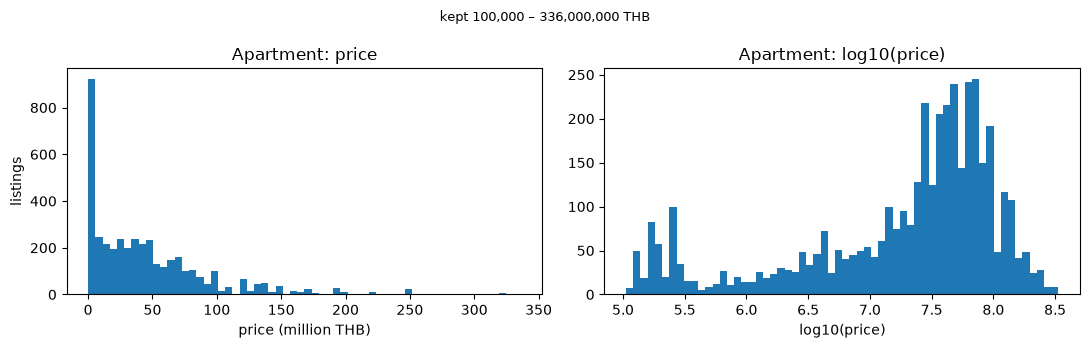

In [33]:
NUMERIC_APARTMENT = ['living_space', 'land_space', 'floor_level']
CATEGORICAL_APARTMENT = ['furnished', 'city', 'state']
FEATURES_APARTMENT = NUMERIC_APARTMENT + CATEGORICAL_APARTMENT
PER_AREA_APARTMENT = None

apartment, X_apartment, price_apartment, hi_price_apartment = prepare(
    df_apartment, required=['living_space', 'city', 'state'],
    numeric=NUMERIC_APARTMENT, categorical=CATEGORICAL_APARTMENT)

# คอลัมน์ข้อความของ Apartment: furnished, city, state
furnished_enc_apartment = LabelEncoder().fit(X_apartment['furnished'])
city_enc_apartment = LabelEncoder().fit(X_apartment['city'])
state_enc_apartment = LabelEncoder().fit(X_apartment['state'])

X_apartment['furnished'] = furnished_enc_apartment.transform(X_apartment['furnished'])
X_apartment['city'] = city_enc_apartment.transform(X_apartment['city'])
X_apartment['state'] = state_enc_apartment.transform(X_apartment['state'])

X_train_apartment, X_test_apartment, price_train_apartment, price_test_apartment = train_test_split(
    X_apartment, price_apartment, test_size=TEST_SIZE, random_state=RANDOM_STATE)

y_train_apartment = to_target(price_train_apartment, X_train_apartment, PER_AREA_APARTMENT)
y_test_apartment = to_target(price_test_apartment, X_test_apartment, PER_AREA_APARTMENT)

print(f'rows={len(apartment):,} จาก {len(df_apartment):,} ({len(apartment) / len(df_apartment):.0%})  '
      f'train={len(X_train_apartment):,}  test={len(X_test_apartment):,}')
print(f'price kept: {MIN_PRICE:,} - {hi_price_apartment:,.0f}')

plot_price_distribution(price_apartment, 'Apartment', hi_price_apartment)

### 10.2 Apartment — DecisionTreeRegressor ค่า default

ค่า default ไม่จำกัดความลึก ต้นไม้จะโตจนจำข้อมูลฝึก (overfit) ใช้เป็น baseline ไว้เทียบ

In [34]:
model_apartment_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_apartment_default.fit(X_train_apartment, y_train_apartment)

res_apartment_default = report(
    model_apartment_default, X_test_apartment, price_test_apartment, 'DT default Apartment', PER_AREA_APARTMENT)

===== DT default Apartment =====
depth  = 27
leaves = 1,675
MAE    : 10,076,639
RMSE   : 28,982,557
R²     : 0.6433
R² log : 0.9157
MdAPE  : 5.2%



### 10.3 Apartment — Tune `max_depth` และ `min_samples_leaf` ด้วย 5-fold CV

`GridSearchCV` แบ่ง **train set** เป็น 5 ส่วน เทรน 4 ส่วนแล้ววัดผลส่วนที่เหลือ วนจนครบ แล้วเฉลี่ย R² จึงไม่แตะ test set เลย

- `max_depth` จำกัดความลึกของต้นไม้
- `min_samples_leaf` บังคับให้ใบแต่ละใบมีข้อมูลอย่างน้อยกี่แถว ช่วยให้ค่าทำนายของแต่ละใบนิ่งขึ้น โดยเฉพาะกลุ่มที่ข้อมูลน้อย

In [35]:
grid_apartment = tune(X_train_apartment, y_train_apartment, 'Apartment')

===== Apartment: CV R² (log price) บน train set =====
           leaf=1  leaf=5  leaf=20
max_depth                         
3          0.8339  0.8339   0.8346
5          0.8827  0.8842   0.8705
8          0.8871  0.8993   0.8813
10         0.8869  0.9020   0.8816
12         0.8862  0.9028   0.8817
15         0.8810  0.9036   0.8817
None       0.8853  0.9037   0.8817
best params : {'max_depth': None, 'min_samples_leaf': 5}
best CV R²  : 0.9037


### 10.4 Apartment — Final model

ใช้ค่าที่ CV เลือก (`grid_apartment.best_params_`) แล้ววัดผลบน test set **ครั้งเดียว**

In [36]:
BEST_PARAMS_APARTMENT = grid_apartment.best_params_
model_apartment = grid_apartment.best_estimator_   # GridSearchCV เทรนใหม่บน train set ทั้งหมดให้แล้ว

res_apartment_tuned = report(
    model_apartment, X_test_apartment, price_test_apartment, 'DT tuned Apartment', PER_AREA_APARTMENT)

===== DT tuned Apartment =====
depth  = 17
leaves = 400
MAE    : 11,349,461
RMSE   : 24,932,483
R²     : 0.7360
R² log : 0.9208
MdAPE  : 15.7%



### 10.5 Apartment — Feature Importance

- `impurity` คือค่า `feature_importances_` ของต้นไม้ เอนเอียงไปทาง feature ที่มีค่าไม่ซ้ำเยอะ (เช่น `city`)
- `permutation` คือ R² (log) ที่ลดลงเมื่อสลับค่าของ feature นั้นใน test set แบบสุ่ม ยิ่งลดมากยิ่งสำคัญ น่าเชื่อถือกว่า

In [37]:
importance_apartment = importance_table(model_apartment, X_test_apartment, y_test_apartment, FEATURES_APARTMENT)
importance_apartment.round(4)

,impurity,permutation
living_space,0.8271,1.1111
land_space,0.0687,0.7810
floor_level,0.0166,0.0732
city,0.0698,0.0426
state,0.0136,0.0315
furnished,0.0042,0.0254


### 10.6 Apartment — ทดลองทำนายของใหม่

`new_apartment` เก็บค่าดิบ (ชื่อเขตเป็นข้อความ) ส่วน `X_new_apartment` คือค่าที่ encode แล้วสำหรับส่งเข้าโมเดล
`median_real_price` จึง map จากชื่อเขตได้ถูกต้อง

In [38]:
furnished_mode_apartment = int(X_train_apartment['furnished'].mode()[0])
city_mode_apartment = int(X_train_apartment['city'].mode()[0])
state_mode_apartment = int(X_train_apartment['state'].mode()[0])

new_apartment = pd.DataFrame([
    {'living_space': 90, 'land_space': 120, 'floor_level': '8',
     'furnished': 'Fully Furnished', 'city': 'Chatuchak',
     'state': 'Bangkok'},
])

X_new_apartment = new_apartment[FEATURES_APARTMENT].copy()
X_new_apartment[NUMERIC_APARTMENT] = X_new_apartment[NUMERIC_APARTMENT].apply(pd.to_numeric, errors='coerce').fillna(-1)
X_new_apartment['furnished'] = encode_column(new_apartment['furnished'], furnished_enc_apartment, furnished_mode_apartment, 'furnished')
X_new_apartment['city'] = encode_column(new_apartment['city'], city_enc_apartment, city_mode_apartment, 'city')
X_new_apartment['state'] = encode_column(new_apartment['state'], state_enc_apartment, state_mode_apartment, 'state')

new_apartment['property_type'] = 'Apartment'
new_apartment['predicted_price'] = predict_price(model_apartment, X_new_apartment, PER_AREA_APARTMENT)

median_apartment = apartment.groupby('city')['price'].median()
new_apartment['median_real_price'] = new_apartment['city'].map(median_apartment)

new_apartment[['property_type', 'living_space', 'land_space', 'state', 'city', 'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,living_space,land_space,state,city,predicted_price,median_real_price
0,Apartment,90,120,Bangkok,Chatuchak,34045164.0,45000000.0


---

# 11) Land

ที่ดินเปล่ามีแค่ 3 คอลัมน์ที่ใช้ได้ (`land_space`, `city`, `state`) เพราะ `living_space` = **0%**

**เปลี่ยน target เป็นราคาต่อหน่วยพื้นที่:** ราคารวมของที่ดิน ≈ ราคาต่อหน่วย × ขนาด ต้นไม้ตัดสินใจเป็นขั้นบันได จึงเรียนรู้การ "คูณ" ได้ไม่ดี
ถ้าให้ต้นไม้ทำนาย `log(ราคา / land_space)` ซึ่งขึ้นกับทำเลเป็นหลัก แล้วคูณ `land_space` กลับตอนท้าย โมเดลจะทำงานง่ายขึ้นมาก
(ใน V2 Land ได้ R² แค่ 0.31)

### 11.1 Land — เตรียมข้อมูลและแบ่ง train/test

rows=24,886 จาก 25,457 (98%)  train=17,420  test=7,466
price kept: 100,000 - 1,363,792,500


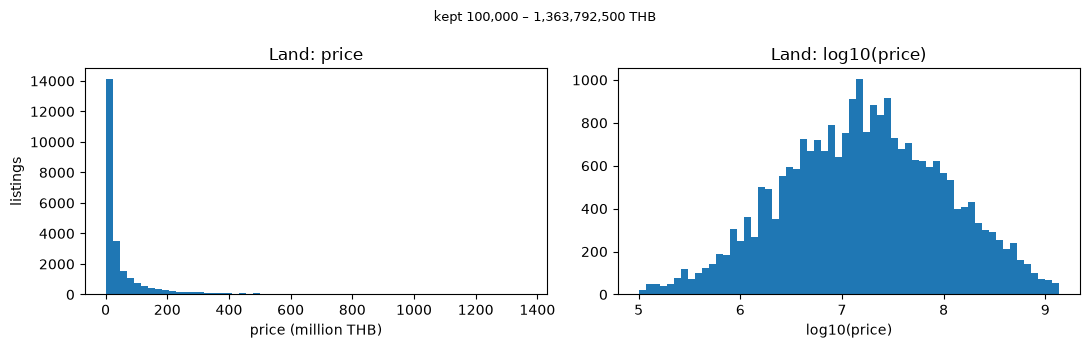

In [39]:
NUMERIC_LAND = ['land_space']
CATEGORICAL_LAND = ['city', 'state']
FEATURES_LAND = NUMERIC_LAND + CATEGORICAL_LAND
PER_AREA_LAND = 'land_space'

land, X_land, price_land, hi_price_land = prepare(
    df_land, required=['land_space', 'city', 'state'],
    numeric=NUMERIC_LAND, categorical=CATEGORICAL_LAND)

# คอลัมน์ข้อความของ Land: city, state
city_enc_land = LabelEncoder().fit(X_land['city'])
state_enc_land = LabelEncoder().fit(X_land['state'])

X_land['city'] = city_enc_land.transform(X_land['city'])
X_land['state'] = state_enc_land.transform(X_land['state'])

X_train_land, X_test_land, price_train_land, price_test_land = train_test_split(
    X_land, price_land, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Land: เทรนบน log ของราคาต่อหน่วยพื้นที่ แล้วคูณพื้นที่กลับตอนทำนาย
y_train_land = to_target(price_train_land, X_train_land, PER_AREA_LAND)
y_test_land = to_target(price_test_land, X_test_land, PER_AREA_LAND)

print(f'rows={len(land):,} จาก {len(df_land):,} ({len(land) / len(df_land):.0%})  '
      f'train={len(X_train_land):,}  test={len(X_test_land):,}')
print(f'price kept: {MIN_PRICE:,} - {hi_price_land:,.0f}')

plot_price_distribution(price_land, 'Land', hi_price_land)

### 11.2 Land — DecisionTreeRegressor ค่า default

ค่า default ไม่จำกัดความลึก ต้นไม้จะโตจนจำข้อมูลฝึก (overfit) ใช้เป็น baseline ไว้เทียบ

In [40]:
model_land_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_land_default.fit(X_train_land, y_train_land)

res_land_default = report(
    model_land_default, X_test_land, price_test_land, 'DT default Land', PER_AREA_LAND)

===== DT default Land =====
depth  = 41
leaves = 12,890
MAE    : 46,197,385
RMSE   : 132,407,030
R²     : 0.1659
R² log : 0.5295
MdAPE  : 44.5%



### 11.3 Land — Tune `max_depth` และ `min_samples_leaf` ด้วย 5-fold CV

`GridSearchCV` แบ่ง **train set** เป็น 5 ส่วน เทรน 4 ส่วนแล้ววัดผลส่วนที่เหลือ วนจนครบ แล้วเฉลี่ย R² จึงไม่แตะ test set เลย

- `max_depth` จำกัดความลึกของต้นไม้
- `min_samples_leaf` บังคับให้ใบแต่ละใบมีข้อมูลอย่างน้อยกี่แถว ช่วยให้ค่าทำนายของแต่ละใบนิ่งขึ้น โดยเฉพาะกลุ่มที่ข้อมูลน้อย

In [41]:
grid_land = tune(X_train_land, y_train_land, 'Land')

===== Land: CV R² (log price) บน train set =====
           leaf=1  leaf=5  leaf=20
max_depth                         
3          0.4366  0.4366   0.4366
5          0.4929  0.4884   0.4822
8          0.5674  0.5651   0.5629
10         0.6145  0.6195   0.6151
12         0.6289  0.6404   0.6357
15         0.6059  0.6412   0.6437
None       0.5301  0.6325   0.6437
best params : {'max_depth': None, 'min_samples_leaf': 20}
best CV R²  : 0.6437


### 11.4 Land — Final model

ใช้ค่าที่ CV เลือก (`grid_land.best_params_`) แล้ววัดผลบน test set **ครั้งเดียว**

In [42]:
BEST_PARAMS_LAND = grid_land.best_params_
model_land = grid_land.best_estimator_   # GridSearchCV เทรนใหม่บน train set ทั้งหมดให้แล้ว

res_land_tuned = report(
    model_land, X_test_land, price_test_land, 'DT tuned Land', PER_AREA_LAND)

===== DT tuned Land =====
depth  = 22
leaves = 646
MAE    : 44,255,318
RMSE   : 117,835,946
R²     : 0.3394
R² log : 0.6472
MdAPE  : 51.4%



### 11.5 Land — Feature Importance

- `impurity` คือค่า `feature_importances_` ของต้นไม้ เอนเอียงไปทาง feature ที่มีค่าไม่ซ้ำเยอะ (เช่น `city`)
- `permutation` คือ R² (log) ที่ลดลงเมื่อสลับค่าของ feature นั้นใน test set แบบสุ่ม ยิ่งลดมากยิ่งสำคัญ น่าเชื่อถือกว่า

In [43]:
importance_land = importance_table(model_land, X_test_land, y_test_land, FEATURES_LAND)
importance_land.round(4)

,impurity,permutation
state,0.5905,0.8970
city,0.1824,0.3433
land_space,0.2271,0.3118


### 11.6 Land — ทดลองทำนายของใหม่

`new_land` เก็บค่าดิบ (ชื่อเขตเป็นข้อความ) ส่วน `X_new_land` คือค่าที่ encode แล้วสำหรับส่งเข้าโมเดล
`median_real_price` จึง map จากชื่อเขตได้ถูกต้อง

In [44]:
city_mode_land = int(X_train_land['city'].mode()[0])
state_mode_land = int(X_train_land['state'].mode()[0])

new_land = pd.DataFrame([
    {'land_space': 500, 'city': 'Bang Plee', 'state': 'Samut Prakan'},   # V2 ใส่ state='Bangkok' ผิด
    {'land_space': 1000, 'city': 'Chatuchak', 'state': 'Bangkok'},
    {'land_space': 1500, 'city': 'Dusit', 'state': 'Bangkok'},
])

X_new_land = new_land[FEATURES_LAND].copy()
X_new_land[NUMERIC_LAND] = X_new_land[NUMERIC_LAND].apply(pd.to_numeric, errors='coerce').fillna(-1)
X_new_land['city'] = encode_column(new_land['city'], city_enc_land, city_mode_land, 'city')
X_new_land['state'] = encode_column(new_land['state'], state_enc_land, state_mode_land, 'state')

new_land['property_type'] = 'Land'
new_land['predicted_price'] = predict_price(model_land, X_new_land, PER_AREA_LAND)

median_land = land.groupby('city')['price'].median()
new_land['median_real_price'] = new_land['city'].map(median_land)

new_land[['property_type', 'land_space', 'state', 'city', 'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,land_space,state,city,predicted_price,median_real_price
0,Land,500,Samut Prakan,Bang Plee,4603348.0,21918500.0
1,Land,1000,Bangkok,Chatuchak,39729119.0,23500000.0
2,Land,1500,Bangkok,Dusit,54578494.0,25450000.0


---

# 12) รวมผลของทั้ง 5 กลุ่ม

ทุกกลุ่มอยู่ในตัวแปรของตัวเองหมดแล้ว (`res_*`, `importance_*`, `new_*`) จึงเอามาวางเทียบกันได้โดยไม่ต้อง train ซ้ำ

### 12.1 จำนวนข้อมูลของแต่ละกลุ่ม

`kept_%` คือสัดส่วนแถวที่ใช้ได้เทียบกับข้อมูลทั้งกลุ่ม ซึ่ง V2 ได้แค่ ~30% (Condo) และ ~15% (บ้านเดี่ยว)

In [45]:
data_summary = pd.DataFrame([
    {'property_type': 'Condo', 'features': len(FEATURES_CONDO),
     'rows_all': len(df_condo), 'rows_used': len(condo),
     'train': len(X_train_condo), 'test': len(X_test_condo), 'price_max': hi_price_condo},
    {'property_type': 'Detached House', 'features': len(FEATURES_HOUSE),
     'rows_all': len(df_house), 'rows_used': len(house),
     'train': len(X_train_house), 'test': len(X_test_house), 'price_max': hi_price_house},
    {'property_type': 'Townhouse', 'features': len(FEATURES_TOWNHOUSE),
     'rows_all': len(df_townhouse), 'rows_used': len(townhouse),
     'train': len(X_train_townhouse), 'test': len(X_test_townhouse), 'price_max': hi_price_townhouse},
    {'property_type': 'Apartment', 'features': len(FEATURES_APARTMENT),
     'rows_all': len(df_apartment), 'rows_used': len(apartment),
     'train': len(X_train_apartment), 'test': len(X_test_apartment), 'price_max': hi_price_apartment},
    {'property_type': 'Land', 'features': len(FEATURES_LAND),
     'rows_all': len(df_land), 'rows_used': len(land),
     'train': len(X_train_land), 'test': len(X_test_land), 'price_max': hi_price_land},
]).set_index('property_type')

data_summary['kept_%'] = data_summary['rows_used'] / data_summary['rows_all'] * 100
data_summary.round(0)

,features,rows_all,rows_used,train,test,price_max,kept_%
property_type,,,,,,,
Condo,8,129129,126431,88501,37930,8.000000e+07,98.0
Detached House,8,42721,38629,27040,11589,1.700000e+08,90.0
Townhouse,8,18697,16095,11266,4829,4.177200e+07,86.0
Apartment,6,4553,4117,2881,1236,3.360000e+08,90.0
Land,3,25457,24886,17420,7466,1.363792e+09,98.0


### 12.2 เปรียบเทียบ default กับ tuned (บน test set)

In [46]:
comparison = pd.DataFrame([
    {'Method': 'DT default Condo', 'params': 'default', **res_condo_default},
    {'Method': 'DT tuned Condo', 'params': str(BEST_PARAMS_CONDO), **res_condo_tuned},
    {'Method': 'DT default Detached House', 'params': 'default', **res_house_default},
    {'Method': 'DT tuned Detached House', 'params': str(BEST_PARAMS_HOUSE), **res_house_tuned},
    {'Method': 'DT default Townhouse', 'params': 'default', **res_townhouse_default},
    {'Method': 'DT tuned Townhouse', 'params': str(BEST_PARAMS_TOWNHOUSE), **res_townhouse_tuned},
    {'Method': 'DT default Apartment', 'params': 'default', **res_apartment_default},
    {'Method': 'DT tuned Apartment', 'params': str(BEST_PARAMS_APARTMENT), **res_apartment_tuned},
    {'Method': 'DT default Land', 'params': 'default', **res_land_default},
    {'Method': 'DT tuned Land', 'params': str(BEST_PARAMS_LAND), **res_land_tuned},
]).set_index('Method')

comparison.round({'MAE': 0, 'RMSE': 0, 'R2': 4, 'R2_log': 4, 'MdAPE': 1})

,params,MAE,RMSE,R2,R2_log,MdAPE
Method,,,,,,
DT default Condo,default,1531713.0,4152208.0,0.8468,0.8625,9.1
DT tuned Condo,"{'max_depth': None, 'min_samples_leaf': 5}",1637586.0,3942246.0,0.8619,0.8783,11.6
DT default Detached House,default,6350067.0,15901424.0,0.4835,0.6700,18.9
DT tuned Detached House,"{'max_depth': None, 'min_samples_leaf': 20}",6266507.0,14027293.0,0.5980,0.7558,24.9
DT default Townhouse,default,1396959.0,3247431.0,0.6357,0.7061,16.2
DT tuned Townhouse,"{'max_depth': 12, 'min_samples_leaf': 20}",1379651.0,2948881.0,0.6996,0.7760,18.1
DT default Apartment,default,10076639.0,28982557.0,0.6433,0.9157,5.2
DT tuned Apartment,"{'max_depth': None, 'min_samples_leaf': 5}",11349461.0,24932483.0,0.7360,0.9208,15.7
DT default Land,default,46197385.0,132407030.0,0.1659,0.5295,44.5


### 12.3 เทียบค่าที่ CV เลือกกับผลจริงบน test set

ถ้า `cv_R2_log` กับ `test_R2_log` ใกล้กัน แปลว่าค่าที่ได้จาก CV เชื่อถือได้ และโมเดลไม่ได้ถูกปรับให้เข้ากับ test set โดยเฉพาะ

In [47]:
best_summary = pd.DataFrame([
    {'property_type': 'Condo', 'max_depth': str(BEST_PARAMS_CONDO['max_depth']),
     'min_samples_leaf': BEST_PARAMS_CONDO['min_samples_leaf'],
     'cv_R2_log': grid_condo.best_score_, 'test_R2_log': res_condo_tuned['R2_log']},
    {'property_type': 'Detached House', 'max_depth': str(BEST_PARAMS_HOUSE['max_depth']),
     'min_samples_leaf': BEST_PARAMS_HOUSE['min_samples_leaf'],
     'cv_R2_log': grid_house.best_score_, 'test_R2_log': res_house_tuned['R2_log']},
    {'property_type': 'Townhouse', 'max_depth': str(BEST_PARAMS_TOWNHOUSE['max_depth']),
     'min_samples_leaf': BEST_PARAMS_TOWNHOUSE['min_samples_leaf'],
     'cv_R2_log': grid_townhouse.best_score_, 'test_R2_log': res_townhouse_tuned['R2_log']},
    {'property_type': 'Apartment', 'max_depth': str(BEST_PARAMS_APARTMENT['max_depth']),
     'min_samples_leaf': BEST_PARAMS_APARTMENT['min_samples_leaf'],
     'cv_R2_log': grid_apartment.best_score_, 'test_R2_log': res_apartment_tuned['R2_log']},
    {'property_type': 'Land', 'max_depth': str(BEST_PARAMS_LAND['max_depth']),
     'min_samples_leaf': BEST_PARAMS_LAND['min_samples_leaf'],
     'cv_R2_log': grid_land.best_score_, 'test_R2_log': res_land_tuned['R2_log']},
]).set_index('property_type')

best_summary.round(4)

,max_depth,min_samples_leaf,cv_R2_log,test_R2_log
property_type,,,,
Condo,None,5,0.8740,0.8783
Detached House,None,20,0.7334,0.7558
Townhouse,12,20,0.7457,0.7760
Apartment,None,5,0.9037,0.9208
Land,None,20,0.6437,0.6472


### 12.4 Feature Importance ของทั้ง 5 กลุ่ม (permutation)

ใช้ค่า permutation เป็นหลัก เพราะวัดจากผลบน test set จริง ค่าใกล้ 0 หรือติดลบแปลว่า feature นั้นแทบไม่ช่วยทำนาย

In [48]:
importance_all = pd.DataFrame({
    'Condo': importance_condo['permutation'],
    'Detached House': importance_house['permutation'],
    'Townhouse': importance_townhouse['permutation'],
    'Apartment': importance_apartment['permutation'],
    'Land': importance_land['permutation'],
}).fillna(0)

importance_all.round(4)

,Condo,Detached House,Townhouse,Apartment,Land
bathroom_number,0.0334,0.2653,0.2428,0.0000,0.0000
bedroom_number,0.0310,0.0087,0.0213,0.0000,0.0000
built_year,0.2128,0.0000,0.0000,0.0000,0.0000
city,0.2165,0.0862,0.0999,0.0426,0.3433
floor_level,0.0438,0.0152,0.0245,0.0732,0.0000
furnished,0.0000,0.0107,0.0025,0.0254,0.0000
land_space,0.0000,0.1346,0.0657,0.7810,0.3118
living_space,1.1986,0.2657,0.2203,1.1111,0.0000
state,0.1223,0.1824,0.1436,0.0315,0.8970
tenure,0.0259,0.0000,0.0000,0.0000,0.0000


**วิธีอ่านตารางนี้**

- ใน V2 (importance แบบ impurity) `living_space` สำคัญที่สุดทุกกลุ่มที่มีพื้นที่ใช้สอย ให้ตรวจว่าแบบ permutation ยังให้ผลเหมือนเดิมหรือไม่
- ถ้า `city` ได้ค่า impurity สูงแต่ permutation ต่ำ แปลว่าต้นไม้ใช้ `city` แบ่งบ่อย แต่การแบ่งเหล่านั้นไม่ได้ช่วยกับข้อมูลใหม่จริง
- สำหรับ Land ค่า `land_space` จะลดลงเมื่อเทียบกับ V2 เป็นเรื่องปกติ เพราะตอนนี้ target คือราคาต่อพื้นที่ ซึ่งขึ้นกับทำเล (`city`, `state`) มากกว่าขนาด ขนาดถูกนำไปคูณกลับนอกโมเดลแล้ว

### 12.5 กราฟเทียบค่า R² ของแต่ละกลุ่ม

ซ้ายคือ R² บนราคาเป็นบาท (เทียบกับ V2 ได้) ขวาคือ R² บน log ราคา (สิ่งที่โมเดลถูกเทรนให้ทำ)

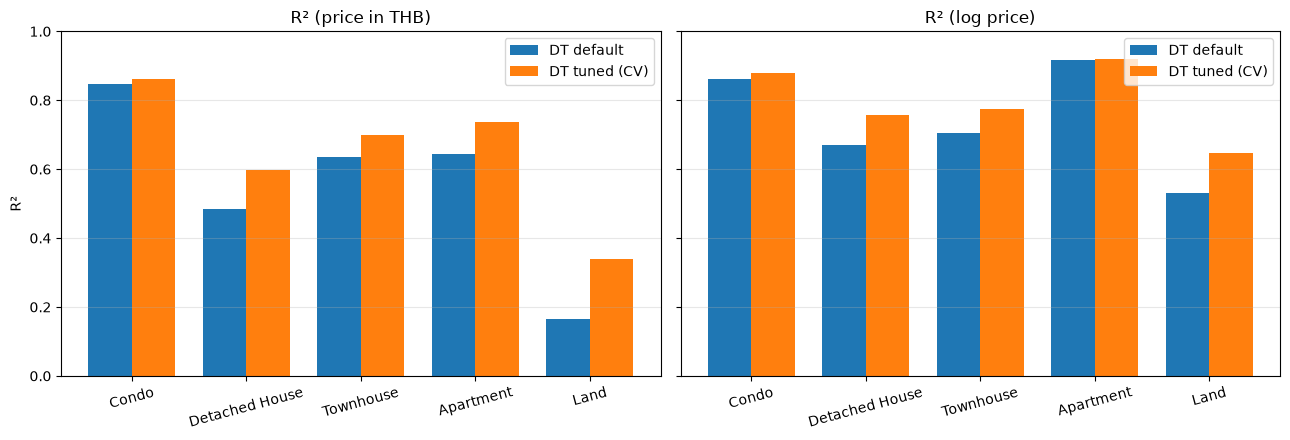

In [49]:
group_names = ['Condo', 'Detached House', 'Townhouse', 'Apartment', 'Land']
res_default_all = [res_condo_default, res_house_default, res_townhouse_default,
                   res_apartment_default, res_land_default]
res_tuned_all = [res_condo_tuned, res_house_tuned, res_townhouse_tuned,
                 res_apartment_tuned, res_land_tuned]

positions = np.arange(len(group_names))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

axes[0].bar(positions - width / 2, [r['R2'] for r in res_default_all], width, label='DT default')
axes[0].bar(positions + width / 2, [r['R2'] for r in res_tuned_all], width, label='DT tuned (CV)')
axes[0].set_title('R² (price in THB)')

axes[1].bar(positions - width / 2, [r['R2_log'] for r in res_default_all], width, label='DT default')
axes[1].bar(positions + width / 2, [r['R2_log'] for r in res_tuned_all], width, label='DT tuned (CV)')
axes[1].set_title('R² (log price)')

axes[0].set_ylabel('R²')
axes[0].set_ylim(min(0, min(r['R2'] for r in res_default_all + res_tuned_all)), 1)
for ax in axes:
    ax.set_xticks(positions)
    ax.set_xticklabels(group_names, rotation=15)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

### 12.6 ตารางราคาที่ทำนายของใหม่ (ทุกกลุ่มรวมกัน)

In [50]:
DISPLAY_COLS = ['property_type', 'living_space', 'land_space', 'state', 'city',
                'predicted_price', 'median_real_price']

result = pd.concat([
    new_condo.reindex(columns=DISPLAY_COLS),
    new_house.reindex(columns=DISPLAY_COLS),
    new_townhouse.reindex(columns=DISPLAY_COLS),
    new_apartment.reindex(columns=DISPLAY_COLS),
    new_land.reindex(columns=DISPLAY_COLS),
], ignore_index=True)

result.round(0).fillna('-')

,property_type,living_space,land_space,state,city,predicted_price,median_real_price
0,Condo,35.0,-,Bangkok,Watthana,7737533.0,9600000.0
1,Condo,120.0,-,Bangkok,Bang Rak,29751613.0,9750000.0
2,Detached House,250.0,400.0,Prachuap Khiri Khan,Hua Hin,8587177.0,8000000.0
3,Detached House,120.0,200.0,Samut Prakan,Bang Plee,3480084.0,8497500.0
4,Townhouse,180.0,200.0,Samut Prakan,Bang Plee,3990234.0,2950000.0
5,Apartment,90.0,120.0,Bangkok,Chatuchak,34045164.0,45000000.0
6,Land,-,500.0,Samut Prakan,Bang Plee,4603348.0,21918500.0
7,Land,-,1000.0,Bangkok,Chatuchak,39729119.0,23500000.0
8,Land,-,1500.0,Bangkok,Dusit,54578494.0,25450000.0


### 12.7 สรุปผลของ tuned model ทุกกลุ่ม

ตารางนี้สร้างจากผลที่รันจริง จึงตรงกับข้อมูลเสมอ (V2 พิมพ์ตัวเลขไว้ใน markdown ซึ่งต้องแก้ด้วยมือทุกครั้งที่รันใหม่)

In [51]:
final_table = pd.DataFrame([
    {'property_type': 'Condo', **res_condo_tuned},
    {'property_type': 'Detached House', **res_house_tuned},
    {'property_type': 'Townhouse', **res_townhouse_tuned},
    {'property_type': 'Apartment', **res_apartment_tuned},
    {'property_type': 'Land', **res_land_tuned},
]).set_index('property_type')

final_table.round({'MAE': 0, 'RMSE': 0, 'R2': 4, 'R2_log': 4, 'MdAPE': 1})

,MAE,RMSE,R2,R2_log,MdAPE
property_type,,,,,
Condo,1637586.0,3942246.0,0.8619,0.8783,11.6
Detached House,6266507.0,14027293.0,0.5980,0.7558,24.9
Townhouse,1379651.0,2948881.0,0.6996,0.7760,18.1
Apartment,11349461.0,24932483.0,0.7360,0.9208,15.7
Land,44255318.0,117835946.0,0.3394,0.6472,51.4


### 12.8 เทียบกับ V2

ผล tuned ของ V2 (อ้างอิง):

| กลุ่ม | max_depth | MAE | RMSE | R² |
|---|---|---|---|---|
| Condo | 15 | 948,467 | 2,134,123 | 0.8722 |
| Detached House | 8 | 5,007,522 | 10,761,332 | 0.5569 |
| Townhouse | 8 | 1,381,549 | 2,532,026 | 0.6945 |
| Apartment | 10 | 8,735,492 | 19,453,523 | 0.8009 |
| Land | 8 | 54,583,452 | 120,781,252 | 0.3059 |

**ข้อควรระวังในการเทียบ**

1. ตัวเลข V2 **ดีเกินจริง** อยู่แล้ว เพราะเลือก depth จาก test set ตัวเลข V3 จึงอาจไม่สูงกว่าในบางกลุ่ม แต่เป็นตัวเลขที่เชื่อถือได้
2. test set ของ V3 **ใหญ่และหลากหลายกว่า** (รวมประกาศที่กรอกไม่ครบ ซึ่ง V2 ทิ้งไป) จึงเป็นโจทย์ที่ยากกว่าและใกล้การใช้งานจริงกว่า
3. ให้ดู `MdAPE` และ `R2_log` ประกอบ ไม่ใช่ R² บาทอย่างเดียว เพราะ R² บาทยังถูกรายการราคาแพงไม่กี่รายการครอบงำ

**ขั้นต่อไปที่ทำได้ ถ้าต้องการให้ผลดีขึ้นอีก**

- ใช้ `RandomForestRegressor` หรือ `HistGradientBoostingRegressor` แทนต้นไม้ต้นเดียว มักได้ R² สูงขึ้นชัดเจน
- แทน `city` ด้วย target encoding (ราคามัธยฐานต่อพื้นที่ของเขต คำนวณจาก train set เท่านั้น)
- สำหรับกลุ่มที่มีบ้าน ลองทำนายราคาต่อ `living_space` แบบเดียวกับ Land